# Explore here

In [7]:
!pip install joblib

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import joblib

sns.set(style="whitegrid")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [9]:
from pathlib import Path

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "src":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PATH = PROJECT_ROOT / "src" / "anime-standalone.csv"
MODEL_DIR = PROJECT_ROOT / "data" / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Directorio actual:", CURRENT_DIR)
print("Raíz del proyecto:", PROJECT_ROOT)
print("Ruta del dataset:", DATA_PATH)
print("Carpeta de modelos:", MODEL_DIR)

Directorio actual: /workspaces/rentarou-ML-web-app-using-Flask-tutorial/src
Raíz del proyecto: /workspaces/rentarou-ML-web-app-using-Flask-tutorial
Ruta del dataset: /workspaces/rentarou-ML-web-app-using-Flask-tutorial/src/anime-standalone.csv
Carpeta de modelos: /workspaces/rentarou-ML-web-app-using-Flask-tutorial/data/models


In [10]:
df = pd.read_csv(DATA_PATH)

df.head()

,id,title,titleJa,titleEn,image,mean,rank,num_list_users,num_scoring_users,num_episodes,start_date,end_date,media_type,status,rating,average_episode_duration,genres,studios
0,1,Cowboy Bebop,カウボーイビバップ,Cowboy Bebop,https://myanimelist.net/images/anime/4/19644.jpg,8.75,49.0,2051529,1059425,26,1998-04-03,1999-04-24,tv,finished_airing,r,1440,"Action, Adult Cast, Award Winning, Sci-Fi, Space",Sunrise
1,5,Cowboy Bebop: Tengoku no Tobira,カウボーイビバップ 天国の扉,Cowboy Bebop: The Movie,https://myanimelist.net/images/anime/1439/9348...,8.38,240.0,411130,231859,1,2001-09-01,2001-09-01,movie,finished_airing,r,6911,"Action, Adult Cast, Sci-Fi, Space",Bones
2,6,Trigun,トライガン,Trigun,https://myanimelist.net/images/anime/1130/1200...,8.22,419.0,832704,400891,26,1998-04-01,1998-09-30,tv,finished_airing,pg_13,1480,"Action, Adult Cast, Adventure, Sci-Fi, Shounen",Madhouse
3,7,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),Witch Hunter Robin,https://myanimelist.net/images/anime/10/19969.jpg,7.25,3527.0,129287,46530,26,2002-07-03,2002-12-25,tv,finished_airing,pg_13,1500,"Action, Detective, Drama, Mystery, Supernatural",Sunrise
4,8,Bouken Ou Beet,冒険王ビィト,Beet the Vandel Buster,https://myanimelist.net/images/anime/7/21569.webp,7.01,4893.0,16881,7226,52,2004-09-30,2005-09-29,tv,finished_airing,pg,1380,"Action, Adventure, Fantasy, Shounen",Toei Animation


In [11]:
print("Shape del dataset:", df.shape)

Shape del dataset: (24923, 18)


In [12]:
df.columns.tolist()

['id',
 'title',
 'titleJa',
 'titleEn',
 'image',
 'mean',
 'rank',
 'num_list_users',
 'num_scoring_users',
 'num_episodes',
 'start_date',
 'end_date',
 'media_type',
 'status',
 'rating',
 'average_episode_duration',
 'genres',
 'studios']

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24923 entries, 0 to 24922
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        24923 non-null  int64  
 1   title                     24923 non-null  str    
 2   titleJa                   24827 non-null  str    
 3   titleEn                   11964 non-null  str    
 4   image                     24817 non-null  str    
 5   mean                      18938 non-null  float64
 6   rank                      18157 non-null  float64
 7   num_list_users            24923 non-null  int64  
 8   num_scoring_users         24923 non-null  int64  
 9   num_episodes              24923 non-null  int64  
 10  start_date                24923 non-null  str    
 11  end_date                  24298 non-null  str    
 12  media_type                24923 non-null  str    
 13  status                    24923 non-null  str    
 14  rating           

In [14]:
df.describe(include="all")

,id,title,titleJa,titleEn,image,mean,rank,num_list_users,num_scoring_users,num_episodes,start_date,end_date,media_type,status,rating,average_episode_duration,genres,studios
count,24923.000000,24923,24827,11964,24817,18938.000000,18157.000000,2.492300e+04,2.492300e+04,24923.000000,24923,24298,24923,24923,24639,24923.000000,24855,17030
unique,NaN,24918,23855,11811,24817,NaN,NaN,NaN,NaN,NaN,9653,9599,10,3,6,NaN,5346,1961
top,NaN,Geomjeong Gomusin,おしりたんてい,Way of Choices,https://myanimelist.net/images/anime/4/19644.jpg,NaN,NaN,NaN,NaN,NaN,2026-07,2023-03-24,tv,finished_airing,pg_13,NaN,Music,Toei Animation
freq,NaN,2,10,6,1,NaN,NaN,NaN,NaN,NaN,51,23,6487,24405,10565,NaN,1961,846
mean,33142.585283,NaN,NaN,NaN,NaN,6.480900,9710.065374,4.681139e+04,2.369004e+04,11.160173,NaN,NaN,NaN,NaN,NaN,1335.280303,NaN,NaN
std,20700.031545,NaN,NaN,NaN,NaN,0.861085,6135.467997,1.849981e+05,1.100954e+05,44.244001,NaN,NaN,NaN,NaN,NaN,1529.406797,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,1.890000,1.000000,2.100000e+01,0.000000e+00,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,10935.500000,NaN,NaN,NaN,NaN,5.870000,4544.000000,4.050000e+02,1.160000e+02,1.000000,NaN,NaN,NaN,NaN,NaN,229.000000,NaN,NaN
50%,36575.000000,NaN,NaN,NaN,NaN,6.460000,9120.000000,2.004000e+03,6.340000e+02,1.000000,NaN,NaN,NaN,NaN,NaN,1099.000000,NaN,NaN
75%,52403.500000,NaN,NaN,NaN,NaN,7.100000,14115.000000,1.409650e+04,5.266500e+03,12.000000,NaN,NaN,NaN,NaN,NaN,1500.000000,NaN,NaN


In [15]:
df["score"] = df["mean"]

df[["title", "mean", "score"]].head()

,title,mean,score
0,Cowboy Bebop,8.75,8.75
1,Cowboy Bebop: Tengoku no Tobira,8.38,8.38
2,Trigun,8.22,8.22
3,Witch Hunter Robin,7.25,7.25
4,Bouken Ou Beet,7.01,7.01


In [16]:
df["high_score"] = np.where(df["score"] >= 8, 1, 0)

df["high_score"].value_counts()

high_score
0    24158
1      765
Name: count, dtype: int64

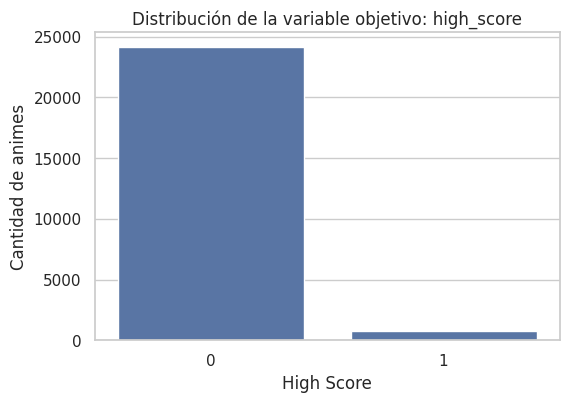

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="high_score")
plt.title("Distribución de la variable objetivo: high_score")
plt.xlabel("High Score")
plt.ylabel("Cantidad de animes")
plt.show()

In [18]:
features = [
    "num_list_users",
    "num_scoring_users",
    "num_episodes",
    "average_episode_duration",
    "media_type",
    "status",
    "rating"
]

target = "high_score"

model_df = df[features + [target]].copy()

model_df.head()

,num_list_users,num_scoring_users,num_episodes,average_episode_duration,media_type,status,rating,high_score
0,2051529,1059425,26,1440,tv,finished_airing,r,1
1,411130,231859,1,6911,movie,finished_airing,r,1
2,832704,400891,26,1480,tv,finished_airing,pg_13,1
3,129287,46530,26,1500,tv,finished_airing,pg_13,0
4,16881,7226,52,1380,tv,finished_airing,pg,0


In [19]:
model_df.isnull().sum()

num_list_users                0
num_scoring_users             0
num_episodes                  0
average_episode_duration      0
media_type                    0
status                        0
rating                      284
high_score                    0
dtype: int64

In [20]:
model_df = model_df.dropna()

print("Nuevo shape:", model_df.shape)

model_df.isnull().sum()

Nuevo shape: (24639, 8)


num_list_users              0
num_scoring_users           0
num_episodes                0
average_episode_duration    0
media_type                  0
status                      0
rating                      0
high_score                  0
dtype: int64

In [21]:
X = model_df[features]

y = model_df[target]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (24639, 7)
Shape de y: (24639,)


In [22]:
numeric_features = [
    "num_list_users",
    "num_scoring_users",
    "num_episodes",
    "average_episode_duration"
]

categorical_features = [
    "media_type",
    "status",
    "rating"
]

print("Columnas numéricas:", numeric_features)
print("Columnas categóricas:", categorical_features)

Columnas numéricas: ['num_list_users', 'num_scoring_users', 'num_episodes', 'average_episode_duration']
Columnas categóricas: ['media_type', 'status', 'rating']


In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

print("Preprocesador creado correctamente.")

Preprocesador creado correctamente.


In [24]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

print("Modelo creado correctamente.")

Modelo creado correctamente.


In [25]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

print("Pipeline creado correctamente.")

Pipeline creado correctamente.


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (19711, 7)
X_test: (4928, 7)
y_train: (19711,)
y_test: (4928,)


In [27]:
pipeline.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [28]:
y_pred = pipeline.predict(X_test)

y_proba = pipeline.predict_proba(X_test)[:, 1]

print("Predicciones generadas correctamente.")

Predicciones generadas correctamente.


In [29]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", round(accuracy, 4))
print("ROC-AUC:", round(roc_auc, 4))

Accuracy: 0.9109
ROC-AUC: 0.9474


In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.92      0.95      4775
           1       0.22      0.76      0.35       153

    accuracy                           0.91      4928
   macro avg       0.61      0.84      0.65      4928
weighted avg       0.97      0.91      0.93      4928



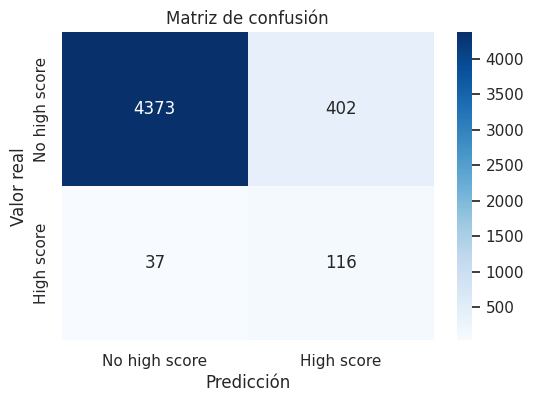

In [31]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No high score", "High score"],
    yticklabels=["No high score", "High score"]
)

plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [32]:
encoded_cat_names = pipeline.named_steps["preprocessor"] \
    .named_transformers_["categorical"] \
    .get_feature_names_out(categorical_features)

all_feature_names = list(encoded_cat_names) + numeric_features

importances = pipeline.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(15)

,feature,importance
18,num_list_users,0.339720
19,num_scoring_users,0.288040
21,average_episode_duration,0.144689
20,num_episodes,0.052185
12,rating_g,0.028466
7,media_type_tv,0.026671
14,rating_pg_13,0.019489
15,rating_r,0.018251
2,media_type_music,0.014000
1,media_type_movie,0.011134


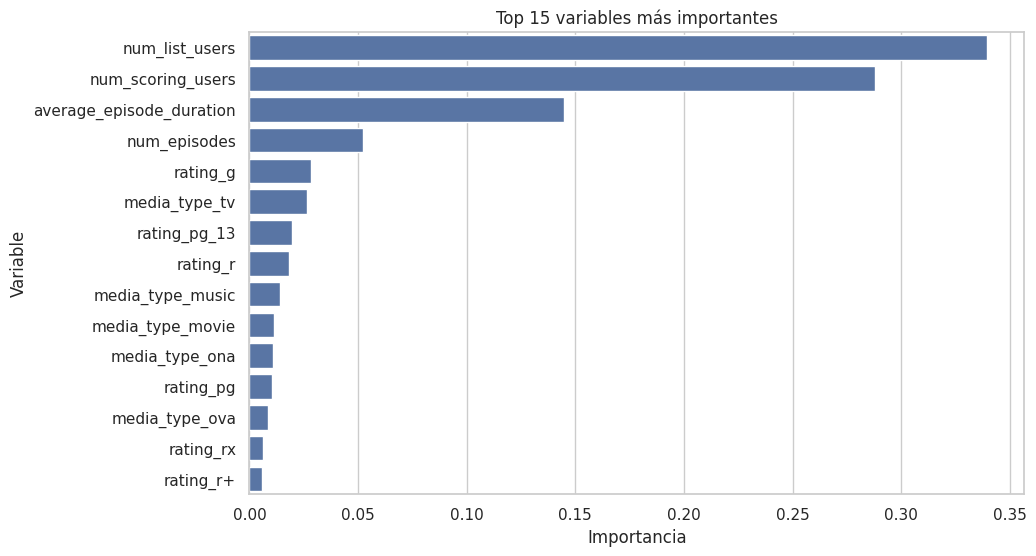

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(15),
    x="importance",
    y="feature"
)

plt.title("Top 15 variables más importantes")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

In [34]:
new_anime = pd.DataFrame([{
    "num_list_users": 500000,
    "num_scoring_users": 250000,
    "num_episodes": 24,
    "average_episode_duration": 1440,
    "media_type": "tv",
    "status": "finished_airing",
    "rating": "pg_13"
}])

prediction = pipeline.predict(new_anime)[0]

probability = pipeline.predict_proba(new_anime)[0][1]

print("Predicción:", prediction)
print("Probabilidad de high_score:", round(probability, 4))

if prediction == 1:
    print("Resultado: El modelo predice que este anime probablemente tendrá puntuación alta.")
else:
    print("Resultado: El modelo predice que este anime probablemente NO tendrá puntuación alta.")

Predicción: 1
Probabilidad de high_score: 0.9288
Resultado: El modelo predice que este anime probablemente tendrá puntuación alta.


In [35]:
MODEL_PATH = MODEL_DIR / "anime_high_score_model.pkl"

joblib.dump(pipeline, MODEL_PATH)

print(f"Modelo guardado en: {MODEL_PATH}")

Modelo guardado en: /workspaces/rentarou-ML-web-app-using-Flask-tutorial/data/models/anime_high_score_model.pkl


In [37]:
FEATURES_PATH = MODEL_DIR / "model_features.pkl"

joblib.dump(features, FEATURES_PATH)

print(f"Lista de features guardada en: {FEATURES_PATH}")

Lista de features guardada en: /workspaces/rentarou-ML-web-app-using-Flask-tutorial/data/models/model_features.pkl


In [38]:
print("Archivos dentro de data/models:")

for file in MODEL_DIR.iterdir():
    print("-", file.name)

Archivos dentro de data/models:
- model_features.pkl
- anime_high_score_model.pkl
